In [29]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit

In [30]:
#Step 2: Load Dataset (ONLY ONCE)
df = pd.read_csv("loan_prediction_dataset.csv")

In [25]:
#Step 3: Dataset Overview
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [31]:
#Step 3 Check Number of rows & columns
df.shape

(614, 13)

In [5]:
#Step 4 Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [35]:
#Step : Statistical Summary of Dataset
df.describe()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,306.500000,0.817590,0.653094,0.744300,0.218241,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296
std,177.390811,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,153.250000,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,306.500000,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,459.750000,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,613.000000,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


In [6]:
#Step 5: Missing Values Check
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [7]:
#Step 6: Handle Missing Values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipython-input-2906803519.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipython-input-2906803519.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [8]:
#Step 7: Check after Handle Missing Values
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [37]:
#Step 8: Encode Categorical Data
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode ONLY remaining object columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [8]:
# Before Encoding
df[['Gender', 'Education']].head()

,Gender,Education
0,Male,Graduate
1,Male,Graduate
2,Male,Graduate
3,Male,Not Graduate
4,Male,Graduate


In [10]:
# After Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Gender', 'Education']:
    df[col] = le.fit_transform(df[col])

df[['Gender', 'Education']].head()

,Gender,Education
0,1,0
1,1,0
2,1,0
3,1,1
4,1,0


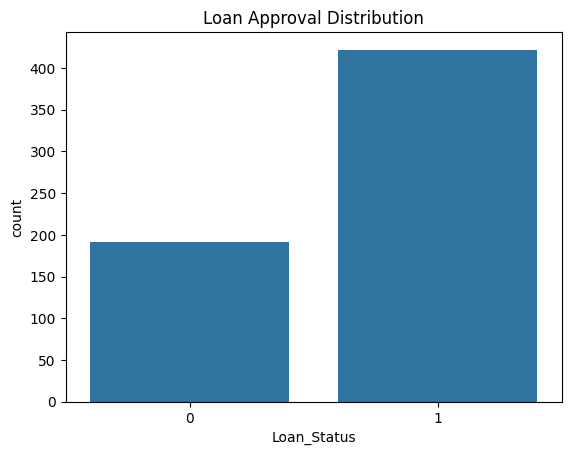

In [10]:
#Step 9: Loan Status Count
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

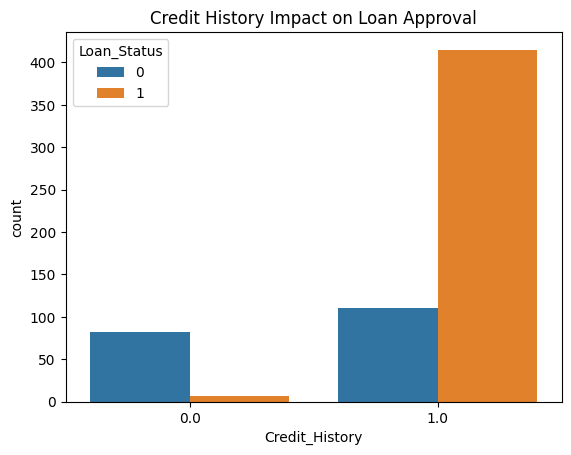

In [11]:
#Step 10: Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History Impact on Loan Approval")
plt.show()

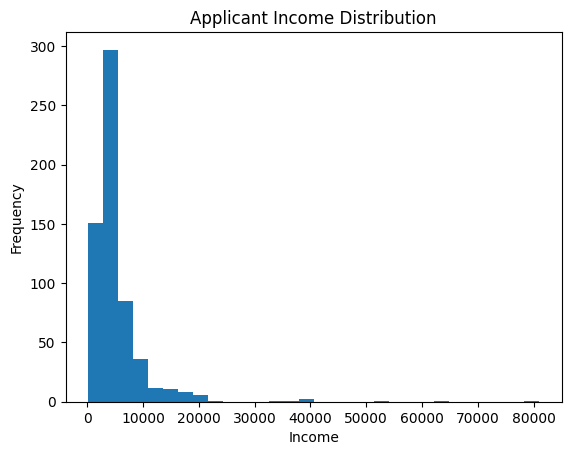

In [12]:
#Step 11: Applicant Income Distribution
plt.hist(df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [38]:
#Step 12: Feature Selection (IMPORTANT)
important_features = [
    'Credit_History',
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Property_Area',
    'Education',
    'Married'
]

X = df[important_features]
y = df['Loan_Status']

In [39]:
#Step 13: Stratified Train–Test Split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(X, y):
    X_train = X.iloc[train_index]
    X_test  = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test  = y.iloc[test_index]

In [13]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


Loan_Status
Y    0.686354
N    0.313646
Name: proportion, dtype: float64
Loan_Status
Y    0.691057
N    0.308943
Name: proportion, dtype: float64


In [35]:
X_train.head()

,Credit_History,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Education,Married
154,1.0,3254,0.0,50.0,360.0,Urban,0,No
239,1.0,3315,0.0,96.0,360.0,Semiurban,0,Yes
448,0.0,3340,1710.0,150.0,360.0,Rural,0,Yes
471,0.0,2653,1500.0,113.0,180.0,Rural,1,Yes
273,1.0,2620,2223.0,150.0,360.0,Semiurban,0,Yes


In [41]:
#Step 14: Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=6,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7804878048780488


In [42]:
#Step 14: Random Forest Model(Advanced)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8536585365853658


In [27]:
#Step 16: Model Evaluation
confusion_matrix(y_test, rf_pred)

array([[23, 15],
       [ 3, 82]])

In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.61      0.72        38
           1       0.85      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



In [34]:
#📊 Model Comparison Table (Decision Tree vs Random Forest)
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy (%)': [round(dt_accuracy * 100, 2), round(rf_accuracy * 100, 2)],
    'Advantage': [
        'Simple and easy to interpret',
        'Higher accuracy and less overfitting'
    ]
})

comparison_df

,Model,Accuracy (%),Advantage
0,Decision Tree,78.86,Simple and easy to interpret
1,Random Forest,85.37,Higher accuracy and less overfitting


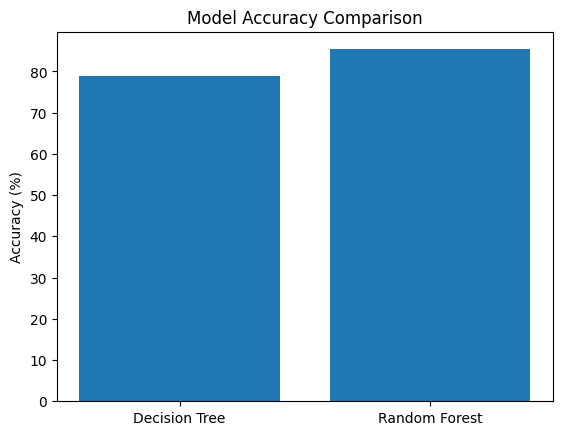

In [30]:
#Step 17: Model Comparison Graph
models = ['Decision Tree', 'Random Forest']
accuracy = [dt_accuracy*100, rf_accuracy*100]

plt.bar(models, accuracy)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.show()

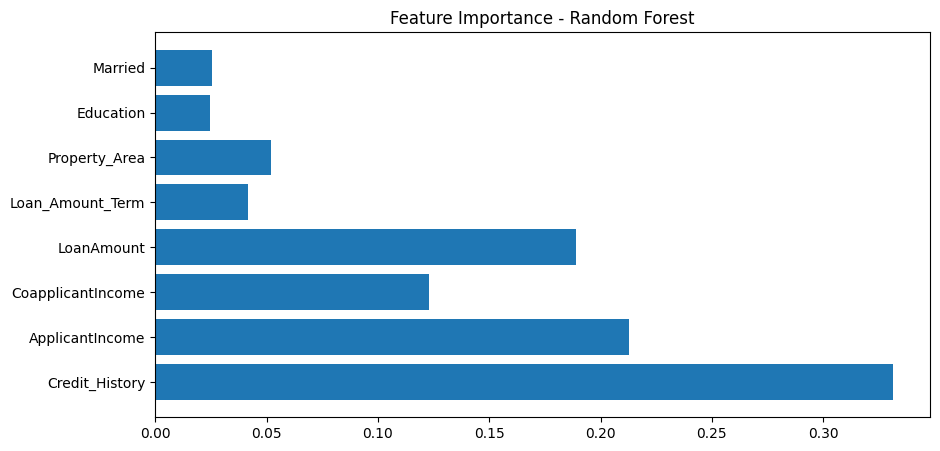

In [31]:
#Feature Importance (Random Forest)
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()

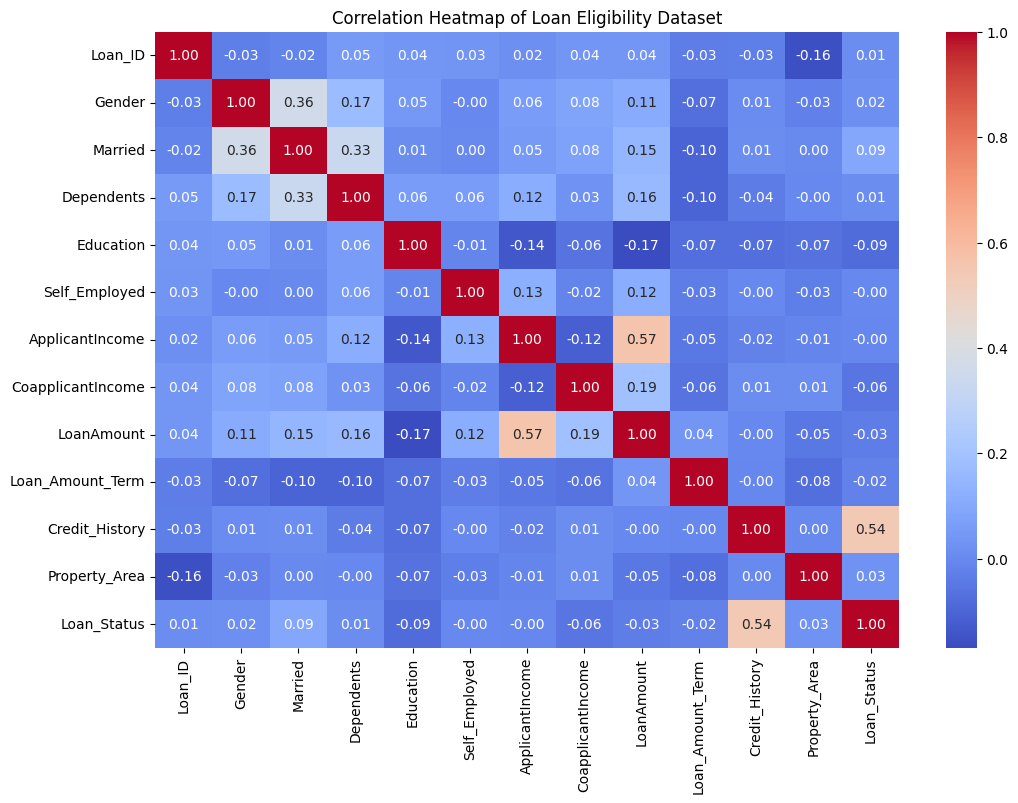

In [32]:
#Step 18: Correlation Heatmap Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Loan Eligibility Dataset")
plt.show()